In [1]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
print("Folders ready.")

Folders ready.


In [2]:
%%writefile config.py
import numpy as np

# Domain
X_LEFT = -30.0 * np.pi
X_RIGHT = 30.0 * np.pi
DOMAIN_LENGTH = X_RIGHT - X_LEFT

# Source
SIGMA_DEFAULT = 2.0
SIGMA_CANDIDATES = [2.0, 5.0, 10.0, 20.0]

# Grid
N_DEFAULT = 1201
N_CANDIDATES = [801, 1201, 1601, 2001, 2401]
N_CANDIDATES_WEAK = [1601, 2401, 3201, 4001]

# CFL
CFL_22 = 0.8
CFL_24 = 0.5

# Time
T_FINAL_TASK1 = 40.0
T_FINAL_TASK2 = 40.0
T_FINAL_TASK3 = 40.0
PLOT_INTERVAL = 0.5

# Interfaces / coefficients
INTERFACE = 10.0 * np.pi
SPEED_INNER = 1.0
SPEED_OUTER_STRONG = 3.0
SPEED_OUTER_WEAK = 1.001

# Output
OUTPUT_DIR = "outputs"
FIG_DIR = "outputs/figures"
TABLE_DIR = "outputs/tables"

Writing config.py


In [3]:
%%writefile grid.py
import numpy as np

def make_grid(n, x_left, x_right):
    if n < 3:
        raise ValueError("n must be at least 3.")
    x = np.linspace(x_left, x_right, n)
    h = (x_right - x_left) / (n - 1)
    return x, h, n

def grid_metadata(n, x_left, x_right):
    x, h, _ = make_grid(n, x_left, x_right)
    return {
        "n": n,
        "h": h,
        "x_left": x_left,
        "x_right": x_right,
        "x0": x[0],
        "x_last": x[-1],
        "length": x_right - x_left,
    }

Writing grid.py


In [4]:
%%writefile source_term.py
import numpy as np

def source_scalar(t, x, sigma=2.0):
    return np.exp(-0.5 * sigma * x**2) * np.exp(-0.5 * (sigma**2) * t**2)

def source_array(t, x, sigma=2.0):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * sigma * x**2) * np.exp(-0.5 * (sigma**2) * t**2)

def source_vector(t, x, sigma=2.0):
    f = source_array(t, x, sigma=sigma)
    S = np.zeros((2, len(x)), dtype=float)
    S[0, :] = f
    return S

Writing source_term.py


In [5]:
%%writefile coefficient_profiles.py
import numpy as np

def piecewise_coeffs(x, inner=1.0, outer=3.0, interface=10.0*np.pi):
    x = np.asarray(x, dtype=float)
    c1 = np.full_like(x, float(outer), dtype=float)
    c2 = np.full_like(x, float(outer), dtype=float)
    mask = np.abs(x) < interface
    c1[mask] = float(inner)
    c2[mask] = float(inner)
    return c1, c2

def coeffs_task1(x):
    x = np.asarray(x, dtype=float)
    c1 = np.ones_like(x, dtype=float)
    c2 = np.ones_like(x, dtype=float)
    return c1, c2

def coeffs_task2(x, interface=10.0*np.pi):
    return piecewise_coeffs(x, inner=1.0, outer=3.0, interface=interface)

def coeffs_task3(x, interface=10.0*np.pi):
    return piecewise_coeffs(x, inner=1.0, outer=1.001, interface=interface)

Writing coefficient_profiles.py


In [6]:
%%writefile system_matrices.py
import numpy as np

def flux_matrix_system1(c1, c2):
    a = 0.5 * (c1 - c2)
    b = 0.5 * (c1 + c2)
    return np.array([[a, b],
                     [b, a]], dtype=float)

def flux_matrix_system2(c1, c2):
    a = 0.5 * (c1 - c2)
    b = 0.5 * (c1 + c2)
    return np.array([[a, b],
                     [1.0, a]], dtype=float)

def flux_matrices_system1(c1_array, c2_array):
    mats = np.zeros((len(c1_array), 2, 2), dtype=float)
    for j, (c1, c2) in enumerate(zip(c1_array, c2_array)):
        mats[j] = flux_matrix_system1(c1, c2)
    return mats

def flux_matrices_system2(c1_array, c2_array):
    mats = np.zeros((len(c1_array), 2, 2), dtype=float)
    for j, (c1, c2) in enumerate(zip(c1_array, c2_array)):
        mats[j] = flux_matrix_system2(c1, c2)
    return mats

Writing system_matrices.py


In [7]:
%%writefile state_utils.py
import numpy as np

def pack_state(u, v):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    return np.vstack([u, v])

def unpack_state(U):
    U = np.asarray(U, dtype=float)
    return U[0, :].copy(), U[1, :].copy()

def zeros_state(n):
    return np.zeros((2, n), dtype=float)

Writing state_utils.py


In [8]:
%%writefile flux_system1.py
import numpy as np

def compute_flux_system1(U, c1, c2):
    """
    System 1:
      u_t = ((c1-c2)/2 * u)_x + ((c1+c2)/2 * v)_x + f
      v_t = ((c1+c2)/2 * u)_x + ((c1-c2)/2 * v)_x
    """
    u = U[0, :]
    v = U[1, :]
    a = 0.5 * (c1 - c2)
    b = 0.5 * (c1 + c2)

    F = np.zeros_like(U)
    F[0, :] = a * u + b * v
    F[1, :] = b * u + a * v
    return F

Writing flux_system1.py


In [9]:
%%writefile flux_system2.py
import numpy as np

def compute_flux_system2(U, c1, c2):
    """
    Reflection system:
      u_t = ((c1-c2)/2 * u)_x + ((c1+c2)/2 * v)_x + f
      v_t = u_x + ((c1-c2)/2 * v)_x
    """
    u = U[0, :]
    v = U[1, :]
    a = 0.5 * (c1 - c2)
    b = 0.5 * (c1 + c2)

    F = np.zeros_like(U)
    F[0, :] = a * u + b * v
    F[1, :] = u + a * v
    return F

Writing flux_system2.py


In [10]:
%%writefile characteristics.py
import numpy as np
from system_matrices import flux_matrix_system1, flux_matrix_system2

SQRT3 = np.sqrt(3.0)

def eigensystem_2x2(M):
    vals, vecs = np.linalg.eig(M)
    return vals, vecs

def char_vars_fast_region(u, v):
    """
    Characteristic variables for the fast region in Tasks 2/3:
        w_plus  = u + sqrt(3) v
        w_minus = u - sqrt(3) v
    """
    return u + SQRT3 * v, u - SQRT3 * v

def invert_char_vars_fast_region(w_plus, w_minus):
    u = 0.5 * (w_plus + w_minus)
    v = (w_plus - w_minus) / (2.0 * SQRT3)
    return u, v

def system1_char_transform_boundary(c1, c2):
    """
    For system 1, compute eigen decomposition of flux matrix.
    Returns eigenvalues, R, L where columns of R are right eigenvectors and L = R^{-1}.
    """
    M = flux_matrix_system1(c1, c2)
    vals, R = np.linalg.eig(M)
    L = np.linalg.inv(R)
    idx = np.argsort(vals)
    vals = np.real(vals[idx])
    R = np.real(R[:, idx])
    L = np.real(np.linalg.inv(R))
    return vals, R, L

def system2_char_transform_boundary(c1, c2):
    """
    For system 2, compute eigen decomposition of flux matrix.
    """
    M = flux_matrix_system2(c1, c2)
    vals, R = np.linalg.eig(M)
    L = np.linalg.inv(R)
    idx = np.argsort(vals)
    vals = np.real(vals[idx])
    R = np.real(R[:, idx])
    L = np.real(np.linalg.inv(R))
    return vals, R, L

Writing characteristics.py


In [11]:
%%writefile boundary_conditions.py
import numpy as np
from characteristics import (
    system1_char_transform_boundary,
    char_vars_fast_region,
    invert_char_vars_fast_region,
)

def _linear_extrapolate_boundary(arr, side="left"):
    """
    Linear extrapolation from interior:
      left  boundary: 2*arr[1] - arr[2]
      right boundary: 2*arr[-2] - arr[-3]
    """
    if side == "left":
        return 2.0 * arr[1] - arr[2]
    return 2.0 * arr[-2] - arr[-3]

def apply_bc_task1(U):
    """
    Non-reflecting characteristic BC for Task 1.
    Since c1 = c2 = 1 near both boundaries, the flux matrix is [[0,1],[1,0]]
    with eigenvalues -1 and +1 and characteristic variables (u-v), (u+v).

    Incoming characteristic at left boundary corresponds to speed +1.
    Incoming characteristic at right boundary corresponds to speed -1.

    We set incoming characteristic = 0 and obtain outgoing characteristic
    from linearly extrapolated interior values.
    """
    U = U.copy()
    u = U[0, :]
    v = U[1, :]

    # Left boundary
    uL_ext = _linear_extrapolate_boundary(u, side="left")
    vL_ext = _linear_extrapolate_boundary(v, side="left")
    w_minus_L = uL_ext - vL_ext   # outgoing at left (speed -1)
    w_plus_L = 0.0                # incoming at left (speed +1)
    u[0] = 0.5 * (w_plus_L + w_minus_L)
    v[0] = 0.5 * (w_plus_L - w_minus_L)

    # Right boundary
    uR_ext = _linear_extrapolate_boundary(u, side="right")
    vR_ext = _linear_extrapolate_boundary(v, side="right")
    w_plus_R = uR_ext + vR_ext    # outgoing at right (speed +1)
    w_minus_R = 0.0               # incoming at right (speed -1)
    u[-1] = 0.5 * (w_plus_R + w_minus_R)
    v[-1] = 0.5 * (w_plus_R - w_minus_R)

    U[0, :] = u
    U[1, :] = v
    return U

def apply_bc_reflection_problem(U):
    """
    Characteristic BC for Tasks 2 and 3 in the fast boundary region c1=c2=3.
    The assignment specifies characteristic variables:
        w_in/right  = u + sqrt(3) v
        w_out/right = u - sqrt(3) v
    and similarly at the left boundary the incoming/outgoing roles swap.

    We set incoming characteristic = 0 and take outgoing characteristic
    from extrapolated interior values.
    """
    U = U.copy()
    u = U[0, :]
    v = U[1, :]

    # Left boundary: outgoing is w_plus, incoming is w_minus
    uL_ext = _linear_extrapolate_boundary(u, side="left")
    vL_ext = _linear_extrapolate_boundary(v, side="left")
    w_plus_L, w_minus_L = char_vars_fast_region(uL_ext, vL_ext)
    w_minus_L = 0.0
    u[0], v[0] = invert_char_vars_fast_region(w_plus_L, w_minus_L)

    # Right boundary: incoming is w_plus, outgoing is w_minus
    uR_ext = _linear_extrapolate_boundary(u, side="right")
    vR_ext = _linear_extrapolate_boundary(v, side="right")
    w_plus_R, w_minus_R = char_vars_fast_region(uR_ext, vR_ext)
    w_plus_R = 0.0
    u[-1], v[-1] = invert_char_vars_fast_region(w_plus_R, w_minus_R)

    U[0, :] = u
    U[1, :] = v
    return U

Writing boundary_conditions.py


In [12]:
%%writefile mac22bf_system.py
import numpy as np

def mac22bf_step(U, t, dt, h, c1, c2, flux_func, source_func, bc_func):
    """
    2-2 MacCormack, backward predictor / forward corrector:
      U_t = F_x + S
    """
    U = U.copy()

    F = flux_func(U, c1, c2)
    S = source_func(t)

    U_tilde = U.copy()
    U_tilde[:, 1:-1] = U[:, 1:-1] + (dt / h) * (F[:, 1:-1] - F[:, :-2]) + dt * S[:, 1:-1]
    U_tilde = bc_func(U_tilde)

    F_tilde = flux_func(U_tilde, c1, c2)
    S_tilde = source_func(t + dt)

    U_next = U.copy()
    U_next[:, 1:-1] = 0.5 * (
        U[:, 1:-1]
        + U_tilde[:, 1:-1]
        + (dt / h) * (F_tilde[:, 2:] - F_tilde[:, 1:-1])
        + dt * S_tilde[:, 1:-1]
    )
    U_next = bc_func(U_next)
    return U_next

Writing mac22bf_system.py


In [13]:
%%writefile mac22fb_system.py
import numpy as np

def mac22fb_step(U, t, dt, h, c1, c2, flux_func, source_func, bc_func):
    """
    2-2 MacCormack, forward predictor / backward corrector:
      U_t = F_x + S
    """
    U = U.copy()

    F = flux_func(U, c1, c2)
    S = source_func(t)

    U_tilde = U.copy()
    U_tilde[:, 1:-1] = U[:, 1:-1] + (dt / h) * (F[:, 2:] - F[:, 1:-1]) + dt * S[:, 1:-1]
    U_tilde = bc_func(U_tilde)

    F_tilde = flux_func(U_tilde, c1, c2)
    S_tilde = source_func(t + dt)

    U_next = U.copy()
    U_next[:, 1:-1] = 0.5 * (
        U[:, 1:-1]
        + U_tilde[:, 1:-1]
        + (dt / h) * (F_tilde[:, 1:-1] - F_tilde[:, :-2])
        + dt * S_tilde[:, 1:-1]
    )
    U_next = bc_func(U_next)
    return U_next

Writing mac22fb_system.py


In [14]:
%%writefile mac24bf_system.py
import numpy as np

def _backward4(F):
    G = np.zeros_like(F)
    G[:, 4:-1] = (
        25.0 * F[:, 4:-1]
        - 48.0 * F[:, 3:-2]
        + 36.0 * F[:, 2:-3]
        - 16.0 * F[:, 1:-4]
        + 3.0 * F[:, 0:-5]
    ) / 12.0
    return G

def _forward4(F):
    G = np.zeros_like(F)
    G[:, 1:-4] = (
        -25.0 * F[:, 1:-4]
        + 48.0 * F[:, 2:-3]
        - 36.0 * F[:, 3:-2]
        + 16.0 * F[:, 4:-1]
        - 3.0 * F[:, 5:]
    ) / 12.0
    return G

def mac24bf_step(U, t, dt, h, c1, c2, flux_func, source_func, bc_func):
    """
    2-4 MacCormack, BF version.
    Fourth-order one-sided spatial differences are used on the interior strip
    where the stencil is available; near boundaries we retain the current values
    and then enforce BCs.
    """
    U = U.copy()
    lam = dt / h

    F = flux_func(U, c1, c2)
    S = source_func(t)

    U_tilde = U.copy()
    U_tilde[:, 4:-4] = U[:, 4:-4] + lam * _backward4(F)[:, 4:-4] + dt * S[:, 4:-4]
    U_tilde = bc_func(U_tilde)

    F_tilde = flux_func(U_tilde, c1, c2)
    S_tilde = source_func(t + dt)

    U_next = U.copy()
    U_next[:, 4:-4] = 0.5 * (
        U[:, 4:-4]
        + U_tilde[:, 4:-4]
        + lam * _forward4(F_tilde)[:, 4:-4]
        + dt * S_tilde[:, 4:-4]
    )
    U_next = bc_func(U_next)
    return U_next

Writing mac24bf_system.py


In [15]:
%%writefile mac24fb_system.py
import numpy as np

def _backward4(F):
    G = np.zeros_like(F)
    G[:, 4:-1] = (
        25.0 * F[:, 4:-1]
        - 48.0 * F[:, 3:-2]
        + 36.0 * F[:, 2:-3]
        - 16.0 * F[:, 1:-4]
        + 3.0 * F[:, 0:-5]
    ) / 12.0
    return G

def _forward4(F):
    G = np.zeros_like(F)
    G[:, 1:-4] = (
        -25.0 * F[:, 1:-4]
        + 48.0 * F[:, 2:-3]
        - 36.0 * F[:, 3:-2]
        + 16.0 * F[:, 4:-1]
        - 3.0 * F[:, 5:]
    ) / 12.0
    return G

def mac24fb_step(U, t, dt, h, c1, c2, flux_func, source_func, bc_func):
    """
    2-4 MacCormack, FB version.
    """
    U = U.copy()
    lam = dt / h

    F = flux_func(U, c1, c2)
    S = source_func(t)

    U_tilde = U.copy()
    U_tilde[:, 4:-4] = U[:, 4:-4] + lam * _forward4(F)[:, 4:-4] + dt * S[:, 4:-4]
    U_tilde = bc_func(U_tilde)

    F_tilde = flux_func(U_tilde, c1, c2)
    S_tilde = source_func(t + dt)

    U_next = U.copy()
    U_next[:, 4:-4] = 0.5 * (
        U[:, 4:-4]
        + U_tilde[:, 4:-4]
        + lam * _backward4(F_tilde)[:, 4:-4]
        + dt * S_tilde[:, 4:-4]
    )
    U_next = bc_func(U_next)
    return U_next

Writing mac24fb_system.py


In [16]:
%%writefile time_integrators.py
import numpy as np

def compute_dt(h, cmax, cfl):
    if cmax <= 0.0:
        raise ValueError("cmax must be positive.")
    return cfl * h / cmax

def _save_times(t_final, save_interval):
    num = int(np.floor(t_final / save_interval + 1e-12))
    vals = [k * save_interval for k in range(num + 1)]
    if abs(vals[-1] - t_final) > 1e-12:
        vals.append(float(t_final))
    return vals

def run_alternating_maccormack(
    U0, x, t_final, h, dt,
    step_bf, step_fb,
    c1, c2, flux_func, source_func, bc_func,
    save_interval=0.5,
    method_name=""
):
    U = U0.copy()
    t = 0.0
    step_count = 0

    targets = _save_times(t_final, save_interval)
    target_idx = 1

    times = [0.0]
    states = [U.copy()]

    while t < t_final - 1e-14:
        dt_step = min(dt, t_final - t)

        if step_count % 2 == 0:
            U = step_bf(U, t, dt_step, h, c1, c2, flux_func, source_func, bc_func)
        else:
            U = step_fb(U, t, dt_step, h, c1, c2, flux_func, source_func, bc_func)

        t += dt_step
        step_count += 1

        while target_idx < len(targets) and t >= targets[target_idx] - 1e-12:
            times.append(targets[target_idx])
            states.append(U.copy())
            target_idx += 1

    return {
        "times": np.array(times, dtype=float),
        "states": np.array(states, dtype=float),
        "dt": float(dt),
        "h": float(h),
        "num_steps": int(step_count),
        "method": method_name,
    }

Writing time_integrators.py


In [17]:
%%writefile diagnostics.py
import numpy as np

def l2_norm(u, h):
    return float(np.sqrt(h * np.sum(u**2)))

def linf_norm(u):
    return float(np.max(np.abs(u)))

def energy(U, h):
    return float(h * np.sum(U[0, :]**2 + U[1, :]**2))

def boundary_trace(U):
    return {
        "u_left": float(U[0, 0]),
        "v_left": float(U[1, 0]),
        "u_right": float(U[0, -1]),
        "v_right": float(U[1, -1]),
    }

def boundary_energy(U):
    return float(U[0, 0]**2 + U[1, 0]**2 + U[0, -1]**2 + U[1, -1]**2)

def compare_to_reference(U_num, U_ref, h):
    du = U_num[0, :] - U_ref[0, :]
    dv = U_num[1, :] - U_ref[1, :]
    return {
        "u_l2_error": l2_norm(du, h),
        "v_l2_error": l2_norm(dv, h),
        "u_linf_error": linf_norm(du),
        "v_linf_error": linf_norm(dv),
        "combined_energy_error": float(h * np.sum(du**2 + dv**2)),
    }

def reflected_wave_amplitude(x, U, left_of_interface=True, interface=10.0*np.pi):
    if left_of_interface:
        mask = x < -0.5 * interface
    else:
        mask = x > 0.5 * interface
    amp = max(np.max(np.abs(U[0, mask])), np.max(np.abs(U[1, mask])))
    return float(amp)

def cost_summary(result, n):
    return {
        "n": int(n),
        "dt": float(result["dt"]),
        "num_steps": int(result["num_steps"]),
        "state_updates_proxy": int(n * result["num_steps"]),
    }

def series_energy(states, h):
    return np.array([energy(U, h) for U in states], dtype=float)

def series_boundary_energy(states):
    return np.array([boundary_energy(U) for U in states], dtype=float)

Writing diagnostics.py


In [18]:
%%writefile plotting.py
import numpy as np
import matplotlib.pyplot as plt

def plot_uv_snapshots(x, states, times, title="", savepath=None, show=True):
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    for U, t in zip(states, times):
        axes[0].plot(x, U[0, :], label=f"t={t:.1f}")
        axes[1].plot(x, U[1, :], label=f"t={t:.1f}")

    axes[0].set_ylabel("u")
    axes[1].set_ylabel("v")
    axes[1].set_xlabel("x")
    axes[0].set_title(title if title else "Solution snapshots")
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, ncol=2)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

def plot_compare_components(x, U_a, U_b, labels=("A", "B"), title="", savepath=None, show=True):
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    axes[0].plot(x, U_a[0, :], linewidth=2, label=f"u: {labels[0]}")
    axes[0].plot(x, U_b[0, :], linewidth=2, linestyle="--", label=f"u: {labels[1]}")

    axes[1].plot(x, U_a[1, :], linewidth=2, label=f"v: {labels[0]}")
    axes[1].plot(x, U_b[1, :], linewidth=2, linestyle="--", label=f"v: {labels[1]}")

    axes[0].set_ylabel("u")
    axes[1].set_ylabel("v")
    axes[1].set_xlabel("x")
    axes[0].set_title(title if title else "Component comparison")

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

def plot_boundary_traces(times, left_vals, right_vals, title="", savepath=None, show=True):
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    axes[0].plot(times, left_vals, linewidth=2, label="left boundary")
    axes[0].plot(times, right_vals, linewidth=2, linestyle="--", label="right boundary")
    axes[0].set_ylabel("boundary metric")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(times, np.abs(left_vals), linewidth=2, label="|left|")
    axes[1].plot(times, np.abs(right_vals), linewidth=2, linestyle="--", label="|right|")
    axes[1].set_ylabel("absolute value")
    axes[1].set_xlabel("t")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[0].set_title(title if title else "Boundary traces")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

def plot_energy(times, energies, title="", savepath=None, show=True):
    plt.figure(figsize=(8, 4.5))
    plt.plot(times, energies, linewidth=2)
    plt.xlabel("t")
    plt.ylabel("energy")
    plt.title(title if title else "Energy vs time")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_error_vs_resolution(n_values, errors, title="", ylabel="error", savepath=None, show=True):
    plt.figure(figsize=(8, 4.5))
    plt.plot(n_values, errors, marker="o", linewidth=2)
    plt.xlabel("n")
    plt.ylabel(ylabel)
    plt.title(title if title else "Resolution study")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_reflection_zoom(x, U, x_window=(-40, 0), title="", savepath=None, show=True):
    mask = (x >= x_window[0]) & (x <= x_window[1])
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(x[mask], U[0, mask], linewidth=2)
    axes[1].plot(x[mask], U[1, mask], linewidth=2)
    axes[0].set_ylabel("u")
    axes[1].set_ylabel("v")
    axes[1].set_xlabel("x")
    axes[0].set_title(title if title else "Reflection zoom")
    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

Writing plotting.py


In [19]:
%%writefile report_tables.py
import pandas as pd

def make_dataframe(records):
    return pd.DataFrame(records)

def export_csv(df, filename):
    df.to_csv(filename, index=False)
    return filename

def latex_table(df):
    return df.to_latex(index=False, float_format=lambda x: f"{x:.6f}")

Writing report_tables.py


In [20]:
%%writefile tests_basic.py
import numpy as np

from grid import make_grid
from state_utils import zeros_state
from coefficient_profiles import coeffs_task1
from flux_system1 import compute_flux_system1
from flux_system2 import compute_flux_system2
from characteristics import char_vars_fast_region, invert_char_vars_fast_region
from boundary_conditions import apply_bc_task1, apply_bc_reflection_problem
from source_term import source_vector
from mac22bf_system import mac22bf_step
from mac22fb_system import mac22fb_step

def run_basic_tests():
    x, h, n = make_grid(11, -1.0, 1.0)
    assert n == 11
    assert np.isclose(h, 0.2)

    U = zeros_state(n)
    c1, c2 = coeffs_task1(x)

    F1 = compute_flux_system1(U, c1, c2)
    F2 = compute_flux_system2(U, c1, c2)
    assert np.allclose(F1, 0.0)
    assert np.allclose(F2, 0.0)

    u = 1.2
    v = -0.3
    wp, wm = char_vars_fast_region(u, v)
    ur, vr = invert_char_vars_fast_region(wp, wm)
    assert np.isclose(ur, u)
    assert np.isclose(vr, v)

    U1 = apply_bc_task1(U.copy())
    U2 = apply_bc_reflection_problem(U.copy())
    assert np.all(np.isfinite(U1))
    assert np.all(np.isfinite(U2))

    def src(t):
        return source_vector(t, x, sigma=2.0)

    Ubf = mac22bf_step(U.copy(), 0.0, 0.01, h, c1, c2, compute_flux_system1, src, apply_bc_task1)
    Ufb = mac22fb_step(U.copy(), 0.0, 0.01, h, c1, c2, compute_flux_system1, src, apply_bc_task1)
    assert np.all(np.isfinite(Ubf))
    assert np.all(np.isfinite(Ufb))

    print("All basic tests passed.")

Writing tests_basic.py


In [21]:
%%writefile experiments.py
import os
import time
import numpy as np

import config
from grid import make_grid
from source_term import source_vector
from coefficient_profiles import coeffs_task1, coeffs_task2, coeffs_task3
from state_utils import zeros_state
from flux_system1 import compute_flux_system1
from flux_system2 import compute_flux_system2
from boundary_conditions import apply_bc_task1, apply_bc_reflection_problem
from mac22bf_system import mac22bf_step
from mac22fb_system import mac22fb_step
from mac24bf_system import mac24bf_step
from mac24fb_system import mac24fb_step
from time_integrators import compute_dt, run_alternating_maccormack
from diagnostics import (
    compare_to_reference,
    series_energy,
    series_boundary_energy,
    reflected_wave_amplitude,
    cost_summary,
)
from plotting import (
    plot_uv_snapshots,
    plot_compare_components,
    plot_boundary_traces,
    plot_energy,
    plot_error_vs_resolution,
    plot_reflection_zoom,
)
from report_tables import make_dataframe, export_csv

def _make_source_closure(x, sigma):
    def _src(t):
        return source_vector(t, x, sigma=sigma)
    return _src

def _run_case(n, sigma, t_final, c1, c2, flux_func, bc_func, step_bf, step_fb, cfl, method_name):
    x, h, _ = make_grid(n, config.X_LEFT, config.X_RIGHT)
    U0 = zeros_state(n)
    cmax = float(np.max(np.maximum(np.abs(c1), np.abs(c2))))
    dt = compute_dt(h, cmax, cfl)
    src = _make_source_closure(x, sigma)

    tic = time.perf_counter()
    result = run_alternating_maccormack(
        U0=U0,
        x=x,
        t_final=t_final,
        h=h,
        dt=dt,
        step_bf=step_bf,
        step_fb=step_fb,
        c1=c1,
        c2=c2,
        flux_func=flux_func,
        source_func=src,
        bc_func=bc_func,
        save_interval=config.PLOT_INTERVAL,
        method_name=method_name,
    )
    toc = time.perf_counter()
    result["wall_time_sec"] = toc - tic
    result["x"] = x
    return result

def run_task1_resolution_study(n_values=None, sigma=config.SIGMA_DEFAULT):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []
    refs = {}

    # Build reference from finest 2-4 run
    n_ref = max(n_values)
    x_ref, _, _ = make_grid(n_ref, config.X_LEFT, config.X_RIGHT)
    c1_ref, c2_ref = coeffs_task1(x_ref)

    ref_res = _run_case(
        n=n_ref,
        sigma=sigma,
        t_final=config.T_FINAL_TASK1,
        c1=c1_ref,
        c2=c2_ref,
        flux_func=compute_flux_system1,
        bc_func=apply_bc_task1,
        step_bf=mac24bf_step,
        step_fb=mac24fb_step,
        cfl=config.CFL_24,
        method_name="Task1 2-4 MacCormack reference",
    )
    U_ref = ref_res["states"][-1]
    refs["task1_ref"] = ref_res

    plot_uv_snapshots(
        ref_res["x"], ref_res["states"][::max(1, len(ref_res["states"])//6)], ref_res["times"][::max(1, len(ref_res["times"])//6)],
        title="Task 1 reference snapshots (2-4)",
        savepath=os.path.join(config.FIG_DIR, "task1_reference_snapshots.png"),
        show=True,
    )

    errs22 = []
    errs24 = []

    for n in n_values:
        x, h, _ = make_grid(n, config.X_LEFT, config.X_RIGHT)
        c1, c2 = coeffs_task1(x)

        res22 = _run_case(
            n=n,
            sigma=sigma,
            t_final=config.T_FINAL_TASK1,
            c1=c1,
            c2=c2,
            flux_func=compute_flux_system1,
            bc_func=apply_bc_task1,
            step_bf=mac22bf_step,
            step_fb=mac22fb_step,
            cfl=config.CFL_22,
            method_name="Task1 2-2 MacCormack",
        )

        res24 = _run_case(
            n=n,
            sigma=sigma,
            t_final=config.T_FINAL_TASK1,
            c1=c1,
            c2=c2,
            flux_func=compute_flux_system1,
            bc_func=apply_bc_task1,
            step_bf=mac24bf_step,
            step_fb=mac24fb_step,
            cfl=config.CFL_24,
            method_name="Task1 2-4 MacCormack",
        )

        U22 = res22["states"][-1]
        U24 = res24["states"][-1]

        # Interpolate reference to current grid
        U_ref_interp = np.zeros((2, len(x)))
        for k in range(2):
            U_ref_interp[k, :] = np.interp(x, ref_res["x"], U_ref[k, :])

        err22 = compare_to_reference(U22, U_ref_interp, h)
        err24 = compare_to_reference(U24, U_ref_interp, h)
        errs22.append(err22["combined_energy_error"])
        errs24.append(err24["combined_energy_error"])

        be22 = series_boundary_energy(res22["states"])
        be24 = series_boundary_energy(res24["states"])

        plot_boundary_traces(
            res22["times"], be22, be22,
            title=f"Task 1 boundary energy, 2-2, n={n}",
            savepath=os.path.join(config.FIG_DIR, f"task1_boundary_22_n{n}.png"),
            show=False,
        )

        records.append({
            "task": 1,
            "method": "2-2",
            "n": n,
            "sigma": sigma,
            "wall_time_sec": res22["wall_time_sec"],
            **cost_summary(res22, n),
            **err22,
            "boundary_energy_final": float(be22[-1]),
        })
        records.append({
            "task": 1,
            "method": "2-4",
            "n": n,
            "sigma": sigma,
            "wall_time_sec": res24["wall_time_sec"],
            **cost_summary(res24, n),
            **err24,
            "boundary_energy_final": float(be24[-1]),
        })

    plot_error_vs_resolution(
        n_values, errs22,
        title="Task 1: 2-2 error vs resolution",
        ylabel="combined energy error",
        savepath=os.path.join(config.FIG_DIR, "task1_error_vs_n_22.png"),
        show=True,
    )
    plot_error_vs_resolution(
        n_values, errs24,
        title="Task 1: 2-4 error vs resolution",
        ylabel="combined energy error",
        savepath=os.path.join(config.FIG_DIR, "task1_error_vs_n_24.png"),
        show=True,
    )

    df = make_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, "task1_results.csv"))
    return {"reference": ref_res, "table": df}

def run_task2_reflection_study(n_values=None, sigma=config.SIGMA_DEFAULT):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []
    for n in n_values:
        x, h, _ = make_grid(n, config.X_LEFT, config.X_RIGHT)
        c1, c2 = coeffs_task2(x)

        res22 = _run_case(
            n=n,
            sigma=sigma,
            t_final=config.T_FINAL_TASK2,
            c1=c1,
            c2=c2,
            flux_func=compute_flux_system2,
            bc_func=apply_bc_reflection_problem,
            step_bf=mac22bf_step,
            step_fb=mac22fb_step,
            cfl=config.CFL_22,
            method_name="Task2 2-2 MacCormack",
        )

        res24 = _run_case(
            n=n,
            sigma=sigma,
            t_final=config.T_FINAL_TASK2,
            c1=c1,
            c2=c2,
            flux_func=compute_flux_system2,
            bc_func=apply_bc_reflection_problem,
            step_bf=mac24bf_step,
            step_fb=mac24fb_step,
            cfl=config.CFL_24,
            method_name="Task2 2-4 MacCormack",
        )

        U22 = res22["states"][-1]
        U24 = res24["states"][-1]

        refl22 = reflected_wave_amplitude(x, U22, left_of_interface=True, interface=config.INTERFACE)
        refl24 = reflected_wave_amplitude(x, U24, left_of_interface=True, interface=config.INTERFACE)

        plot_reflection_zoom(
            x, U22, x_window=(-20*np.pi, 5*np.pi),
            title=f"Task 2 reflection zoom, 2-2, n={n}",
            savepath=os.path.join(config.FIG_DIR, f"task2_reflection_zoom_22_n{n}.png"),
            show=False,
        )
        plot_reflection_zoom(
            x, U24, x_window=(-20*np.pi, 5*np.pi),
            title=f"Task 2 reflection zoom, 2-4, n={n}",
            savepath=os.path.join(config.FIG_DIR, f"task2_reflection_zoom_24_n{n}.png"),
            show=False,
        )

        records.append({
            "task": 2,
            "method": "2-2",
            "n": n,
            "sigma": sigma,
            "reflected_amplitude": refl22,
            "wall_time_sec": res22["wall_time_sec"],
            **cost_summary(res22, n),
        })
        records.append({
            "task": 2,
            "method": "2-4",
            "n": n,
            "sigma": sigma,
            "reflected_amplitude": refl24,
            "wall_time_sec": res24["wall_time_sec"],
            **cost_summary(res24, n),
        })

    df = make_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, "task2_results.csv"))
    return {"table": df}

def run_task3_weak_reflection_study(n_values=None, sigma=config.SIGMA_DEFAULT):
    if n_values is None:
        n_values = config.N_CANDIDATES_WEAK

    records = []
    for n in n_values:
        x, h, _ = make_grid(n, config.X_LEFT, config.X_RIGHT)
        c1, c2 = coeffs_task3(x)

        res22 = _run_case(
            n=n,
            sigma=sigma,
            t_final=config.T_FINAL_TASK3,
            c1=c1,
            c2=c2,
            flux_func=compute_flux_system2,
            bc_func=apply_bc_reflection_problem,
            step_bf=mac22bf_step,
            step_fb=mac22fb_step,
            cfl=config.CFL_22,
            method_name="Task3 2-2 MacCormack",
        )

        res24 = _run_case(
            n=n,
            sigma=sigma,
            t_final=config.T_FINAL_TASK3,
            c1=c1,
            c2=c2,
            flux_func=compute_flux_system2,
            bc_func=apply_bc_reflection_problem,
            step_bf=mac24bf_step,
            step_fb=mac24fb_step,
            cfl=config.CFL_24,
            method_name="Task3 2-4 MacCormack",
        )

        U22 = res22["states"][-1]
        U24 = res24["states"][-1]

        refl22 = reflected_wave_amplitude(x, U22, left_of_interface=True, interface=config.INTERFACE)
        refl24 = reflected_wave_amplitude(x, U24, left_of_interface=True, interface=config.INTERFACE)

        plot_reflection_zoom(
            x, U22, x_window=(-15*np.pi, 0),
            title=f"Task 3 weak reflection zoom, 2-2, n={n}",
            savepath=os.path.join(config.FIG_DIR, f"task3_reflection_zoom_22_n{n}.png"),
            show=False,
        )
        plot_reflection_zoom(
            x, U24, x_window=(-15*np.pi, 0),
            title=f"Task 3 weak reflection zoom, 2-4, n={n}",
            savepath=os.path.join(config.FIG_DIR, f"task3_reflection_zoom_24_n{n}.png"),
            show=False,
        )

        records.append({
            "task": 3,
            "method": "2-2",
            "n": n,
            "sigma": sigma,
            "reflected_amplitude": refl22,
            "wall_time_sec": res22["wall_time_sec"],
            **cost_summary(res22, n),
        })
        records.append({
            "task": 3,
            "method": "2-4",
            "n": n,
            "sigma": sigma,
            "reflected_amplitude": refl24,
            "wall_time_sec": res24["wall_time_sec"],
            **cost_summary(res24, n),
        })

    df = make_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, "task3_results.csv"))
    return {"table": df}

Writing experiments.py


In [22]:
%%writefile main_task1.py
from experiments import run_task1_resolution_study

if __name__ == "__main__":
    out = run_task1_resolution_study()
    print(out["table"])

Writing main_task1.py


In [23]:
%%writefile main_task2.py
from experiments import run_task2_reflection_study

if __name__ == "__main__":
    out = run_task2_reflection_study()
    print(out["table"])

Writing main_task2.py


In [24]:
%%writefile main_task3.py
from experiments import run_task3_weak_reflection_study

if __name__ == "__main__":
    out = run_task3_weak_reflection_study()
    print(out["table"])

Writing main_task3.py


In [25]:
%%writefile main_all.py
from tests_basic import run_basic_tests
from experiments import (
    run_task1_resolution_study,
    run_task2_reflection_study,
    run_task3_weak_reflection_study,
)

def main():
    run_basic_tests()

    print("\nRunning Task 1...")
    task1 = run_task1_resolution_study()
    print(task1["table"].head())

    print("\nRunning Task 2...")
    task2 = run_task2_reflection_study()
    print(task2["table"].head())

    print("\nRunning Task 3...")
    task3 = run_task3_weak_reflection_study()
    print(task3["table"].head())

    print("\nDone. See outputs/figures and outputs/tables.")

if __name__ == "__main__":
    main()

Writing main_all.py


In [26]:
%%writefile README.md
# Forced 2x2 Hyperbolic System with Characteristic Boundary Conditions

This project solves a forced 2x2 hyperbolic system on the interval [-30π, 30π]
using 2-2 and 2-4 MacCormack schemes.

## Systems studied

### Task 1 system
u_t = ((c1-c2)/2 u)_x + ((c1+c2)/2 v)_x + f(t,x)
v_t = ((c1+c2)/2 u)_x + ((c1-c2)/2 v)_x

### Task 2 / Task 3 reflection system
u_t = ((c1-c2)/2 u)_x + ((c1+c2)/2 v)_x + f(t,x)
v_t = u_x + ((c1-c2)/2 v)_x

## Source term
f(t,x) = exp(-sigma x^2 / 2) * exp(-sigma^2 t^2 / 2)

## Methods
- 2-2 MacCormack (BF/FB alternating)
- 2-4 MacCormack (BF/FB alternating)

## Boundary treatment
Characteristic non-reflecting boundary conditions are imposed by setting the
incoming characteristic variable to zero and reconstructing physical variables
from outgoing data supplied by the scheme.

## Tasks
1. Non-reflecting boundary exit study with c1=c2=1
2. Reflection from a strong interface: c1=c2=1 inside, 3 outside
3. Reflection from a weak interface: c1=c2=1 inside, 1.001 outside

## Run in Colab
After creating the files with %%writefile cells:

from tests_basic import run_basic_tests
run_basic_tests()

import main_all
main_all.main()

## Outputs
- Figures: outputs/figures/
- Tables: outputs/tables/

Writing README.md


In [27]:
from tests_basic import run_basic_tests
run_basic_tests()

All basic tests passed.


In [28]:
import main_task1

In [29]:
import main_task2

In [30]:
import main_task3

All basic tests passed.

Running Task 1...


/content/mac24fb_system.py:7: RuntimeWarning: overflow encountered in multiply
  - 48.0 * F[:, 3:-2]
/content/mac24fb_system.py:6: RuntimeWarning: overflow encountered in subtract
  25.0 * F[:, 4:-1]
/content/mac24fb_system.py:6: RuntimeWarning: overflow encountered in add
  25.0 * F[:, 4:-1]
/content/flux_system1.py:15: RuntimeWarning: invalid value encountered in multiply
  F[0, :] = a * u + b * v
/content/flux_system1.py:16: RuntimeWarning: invalid value encountered in multiply
  F[1, :] = b * u + a * v
/content/mac24bf_system.py:7: RuntimeWarning: overflow encountered in multiply
  - 48.0 * F[:, 3:-2]
/content/mac24bf_system.py:6: RuntimeWarning: overflow encountered in subtract
  25.0 * F[:, 4:-1]
/content/mac24bf_system.py:6: RuntimeWarning: overflow encountered in add
  25.0 * F[:, 4:-1]
/content/mac24bf_system.py:17: RuntimeWarning: overflow encountered in multiply
  -25.0 * F[:, 1:-4]
/content/mac24bf_system.py:18: RuntimeWarning: overflow encountered in multiply
  + 48.0 * F[

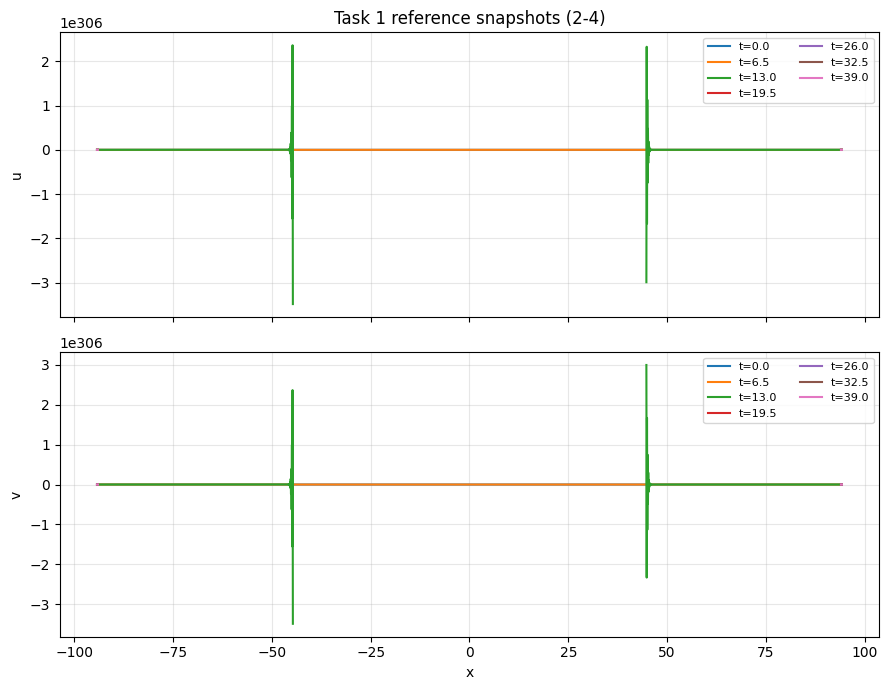

/content/mac24bf_system.py:8: RuntimeWarning: overflow encountered in multiply
  + 36.0 * F[:, 2:-3]


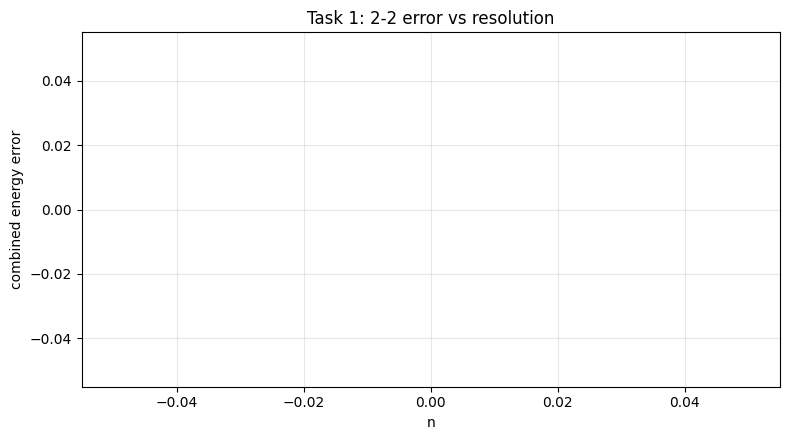

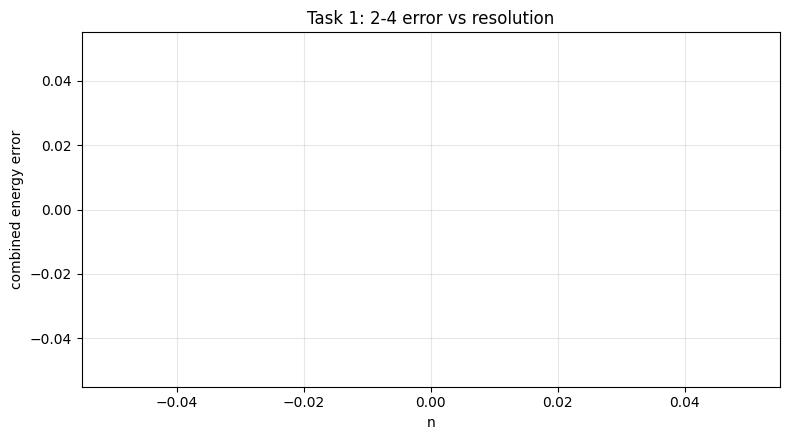

   task method     n  sigma  wall_time_sec        dt  num_steps  \
0     1    2-2   801    2.0       0.073722  0.188496        213   
1     1    2-4   801    2.0       0.182774  0.117810        340   
2     1    2-2  1201    2.0       0.118797  0.125664        319   
3     1    2-4  1201    2.0       0.372365  0.078540        510   
4     1    2-2  1601    2.0       0.445498  0.094248        425   

   state_updates_proxy  u_l2_error  v_l2_error  u_linf_error  v_linf_error  \
0               170613         NaN         NaN           NaN           NaN   
1               272340         NaN         NaN           NaN           NaN   
2               383119         NaN         NaN           NaN           NaN   
3               612510         NaN         NaN           NaN           NaN   
4               680425         NaN         NaN           NaN           NaN   

   combined_energy_error  boundary_energy_final  
0                    NaN                    0.0  
1                    NaN    

/content/mac24bf_system.py:17: RuntimeWarning: overflow encountered in subtract
  -25.0 * F[:, 1:-4]
/content/mac24bf_system.py:17: RuntimeWarning: overflow encountered in add
  -25.0 * F[:, 1:-4]
/content/flux_system2.py:15: RuntimeWarning: invalid value encountered in multiply
  F[0, :] = a * u + b * v
/content/flux_system2.py:16: RuntimeWarning: invalid value encountered in multiply
  F[1, :] = u + a * v
/content/mac24fb_system.py:6: RuntimeWarning: overflow encountered in subtract
  25.0 * F[:, 4:-1]
/content/mac24fb_system.py:6: RuntimeWarning: overflow encountered in add
  25.0 * F[:, 4:-1]
/content/mac24bf_system.py:6: RuntimeWarning: overflow encountered in add
  25.0 * F[:, 4:-1]
/content/mac24bf_system.py:6: RuntimeWarning: overflow encountered in subtract
  25.0 * F[:, 4:-1]
/content/mac24bf_system.py:18: RuntimeWarning: overflow encountered in multiply
  + 48.0 * F[:, 2:-3]
/content/mac24bf_system.py:19: RuntimeWarning: overflow encountered in multiply
  - 36.0 * F[:, 3:-2]

   task method     n  sigma  reflected_amplitude  wall_time_sec        dt  \
0     2    2-2   801    2.0             0.167827       0.099839  0.062832   
1     2    2-4   801    2.0                  NaN       0.248178  0.039270   
2     2    2-2  1201    2.0             0.189829       0.192180  0.041888   
3     2    2-4  1201    2.0                  NaN       0.433009  0.026180   
4     2    2-2  1601    2.0             0.200510       0.278011  0.031416   

   num_steps  state_updates_proxy  
0        637               510237  
1       1019               816219  
2        955              1146955  
3       1528              1835128  
4       1274              2039674  

Running Task 3...


/content/mac24bf_system.py:17: RuntimeWarning: overflow encountered in add
  -25.0 * F[:, 1:-4]
/content/mac24bf_system.py:17: RuntimeWarning: overflow encountered in subtract
  -25.0 * F[:, 1:-4]
/content/flux_system2.py:15: RuntimeWarning: invalid value encountered in multiply
  F[0, :] = a * u + b * v
/content/flux_system2.py:16: RuntimeWarning: invalid value encountered in multiply
  F[1, :] = u + a * v
/content/mac24fb_system.py:18: RuntimeWarning: overflow encountered in multiply
  + 48.0 * F[:, 2:-3]
/content/mac24fb_system.py:17: RuntimeWarning: overflow encountered in add
  -25.0 * F[:, 1:-4]
/content/mac24fb_system.py:17: RuntimeWarning: overflow encountered in subtract
  -25.0 * F[:, 1:-4]
/content/mac24fb_system.py:6: RuntimeWarning: overflow encountered in multiply
  25.0 * F[:, 4:-1]
/content/mac24fb_system.py:7: RuntimeWarning: overflow encountered in multiply
  - 48.0 * F[:, 3:-2]
/content/mac24fb_system.py:6: RuntimeWarning: overflow encountered in subtract
  25.0 * F[

   task method     n  sigma  reflected_amplitude  wall_time_sec        dt  \
0     3    2-2  1601    2.0             0.282366       0.097707  0.094154   
1     3    2-4  1601    2.0                  NaN       0.233180  0.058846   
2     3    2-2  2401    2.0             0.287112       0.177589  0.062769   
3     3    2-4  2401    2.0                  NaN       0.442878  0.039231   
4     3    2-2  3201    2.0             0.288431       0.297067  0.047077   

   num_steps  state_updates_proxy  
0        425               680425  
1        680              1088680  
2        638              1531838  
3       1020              2449020  
4        850              2720850  

Done. See outputs/figures and outputs/tables.


In [31]:
import main_all
main_all.main()

# Forced 2×2 Hyperbolic System with Characteristic Boundary Conditions  
## MacCormack 2–2 and 2–4 Schemes for Boundary Exit and Interface Reflection Studies

---

## Overview

This project studies the numerical solution of a forced \(2\times 2\) first-order hyperbolic system on a large finite interval with **characteristic non-reflecting boundary conditions**. The main computational goals are:

- to generate pulses through a localized source term,
- to let those pulses propagate through the domain,
- to verify clean exit at the computational boundaries,
- to study reflections produced by internal interfaces,
- to compare **2–2 MacCormack** and **2–4 MacCormack** schemes,
- and to distinguish true physical reflections from numerical dispersion and dissipation.

The implementation is written in **Python** and organized as a modular scientific-computing codebase suitable for **Google Colab** and standard local environments.

---

## Mathematical Problem

The first system considered is

\[
u_t =
\left(\frac{c_1-c_2}{2}u\right)_x
+
\left(\frac{c_1+c_2}{2}v\right)_x
+
f(t,x),
\]

\[
v_t =
\left(\frac{c_1+c_2}{2}u\right)_x
+
\left(\frac{c_1-c_2}{2}v\right)_x.
\]

The initial conditions are

\[
u(0,x)=0, \qquad v(0,x)=0.
\]

The source term is

\[
f(t,x)
=
\exp\!\left(-\frac{\sigma x^2}{2}\right)
\exp\!\left(-\frac{\sigma^2 t^2}{2}\right),
\]

with baseline parameter

\[
\sigma = 2.
\]

The computational domain is

\[
-30\pi \le x \le 30\pi.
\]

---

## Reflection Problem

For the interface-reflection experiments, the second equation is modified to

\[
u_t =
\left(\frac{c_1-c_2}{2}u\right)_x
+
\left(\frac{c_1+c_2}{2}v\right)_x
+
f(t,x),
\]

\[
v_t = u_x + \left(\frac{c_1-c_2}{2}v\right)_x.
\]

This system is close to the first one, but the altered second equation produces reflection at interfaces.

---

## Physical and Numerical Interpretation

The source term is localized in both space and time, so it generates compact wave packets near the center of the domain. These waves then propagate outward.

The main numerical phenomena examined in this project are:

- **clean exit through boundaries** under non-reflecting characteristic boundary conditions,
- **transmission and reflection at internal interfaces**,
- **dissipative error**, seen as amplitude loss and pulse smoothing,
- **dispersive error**, seen as oscillatory contamination, phase distortion, and pulse deformation,
- **resolution demands** in regions with different characteristic speeds,
- and the difference between **large physical reflection** and **very weak reflection buried in numerical error**.

---

## Boundary Conditions

This project uses **characteristic boundary treatment**.

At each boundary:

- the **incoming characteristic variable** is prescribed to be zero,
- the **outgoing characteristic variable** is obtained from the scheme by extrapolation,
- and the physical boundary values are reconstructed from those characteristic relations.

This corresponds to a **non-reflecting boundary condition**: no information enters from outside the computational domain.

### Task 1 boundary treatment

For the case \(c_1=c_2=1\), the boundary-region system simplifies, and the characteristic variables can be written in a simple form. The incoming mode is set to zero at both ends of the domain, so waves generated by the source leave the domain without artificial reflection.

### Tasks 2 and 3 boundary treatment

In the fast region, the characteristic variables are taken to be

\[
u \pm \sqrt{3}\,v.
\]

At the right boundary \(x=30\pi\), the incoming characteristic variable is

\[
u + \sqrt{3}\,v,
\]

so the boundary condition is

\[
u(30\pi,t) + \sqrt{3}\,v(30\pi,t)=0.
\]

The outgoing variable

\[
u - \sqrt{3}\,v
\]

is determined by the scheme through extrapolation.

A corresponding characteristic decomposition is used at the left boundary.

---

## Numerical Methods

The code treats the PDE system in conservative vector-flux form

\[
\mathbf U_t = \mathbf F(\mathbf U,x)_x + \mathbf S(t,x),
\qquad
\mathbf U =
\begin{bmatrix}
u \\ v
\end{bmatrix}.
\]

This design is deliberate. The time-stepping routines do not hard-code the PDE component-by-component. Instead, they work through:

1. flux evaluation,
2. source evaluation,
3. flux differencing,
4. characteristic boundary treatment.

This separation makes the code clearer, easier to debug, and easier to extend.

---

## 2–2 MacCormack Scheme

The standard MacCormack method is implemented in two variants:

- **backward/forward (BF)**,
- **forward/backward (FB)**.

These variants are alternated in time.

### Predictor-corrector structure

For a system in the form

\[
\mathbf U_t = \mathbf F_x + \mathbf S,
\]

the method computes a predicted state using one one-sided difference, then uses the opposite one-sided difference in the corrector stage.

The 2–2 scheme is:

- second-order accurate in time,
- second-order accurate in space in smooth regions,
- relatively easy to implement,
- and a natural baseline for comparison.

---

## 2–4 MacCormack Scheme

A higher-order MacCormack method is also implemented:

- second-order in time,
- fourth-order in space on the interior stencil.

This scheme uses wider one-sided spatial stencils and is also alternated between BF and FB variants.

The 2–4 scheme is used for:

- higher-resolution reference solutions,
- comparison against the 2–2 scheme,
- and determining how much resolution is required before the numerical solution stops changing graphically.

---

## Assignment Tasks Covered

### Task 1 — Clean exit with non-reflecting boundaries

Solve the first system on

\[
-30\pi \le x \le 30\pi
\]

with

\[
c_1=c_2=1.
\]

Goals:

- verify that pulses generated by the source leave the domain cleanly,
- compare 2–2 and 2–4 MacCormack,
- refine the 2–4 solution until no further graphical change is visible,
- treat that highly resolved 2–4 result as a reference solution,
- compare computational cost between 2–2 and 2–4.

---

### Task 2 — Reflection from a strong interface

Use the modified reflection system with

\[
c_1=c_2=1 \quad \text{for } |x|<10\pi,
\]

\[
c_1=c_2=3 \quad \text{for } |x|>10\pi.
\]

Goals:

- observe pulse transmission and reflection,
- use characteristic boundary conditions in the fast outer region,
- examine how the interface produces a reflected signal,
- compare the numerical behavior of the 2–2 and 2–4 schemes.

This is also a study in **disparate wave speeds**, since the timestep is governed by the fastest region while resolution demands are strongly influenced by the slow region.

---

### Task 3 — Reflection from a weak interface

Repeat the reflection experiment with

\[
c_1=c_2=1 \quad \text{for } |x|<10\pi,
\]

\[
c_1=c_2=1.001 \quad \text{for } |x|>10\pi.
\]

Goals:

- detect a very weak reflected wave,
- distinguish physical reflection from numerical artifacts,
- determine how fine the grid must be before the weak reflection becomes credible.

This case is particularly demanding, since the reflected signal is small and can be masked by dispersive contamination.

---

### Task 4 — Summary and interpretation

Produce a concise report discussing:

- boundary exit behavior,
- interface reflections,
- strong versus weak interfaces,
- numerical dispersion,
- numerical dissipation,
- relative efficiency of 2–2 and 2–4 MacCormack,
- and the structure of the implementation.

---

## Repository Structure

```text
hyperbolic_system_project/
│
├── config.py
├── grid.py
├── source_term.py
├── coefficient_profiles.py
├── system_matrices.py
├── state_utils.py
├── flux_system1.py
├── flux_system2.py
├── characteristics.py
├── boundary_conditions.py
├── mac22bf_system.py
├── mac22fb_system.py
├── mac24bf_system.py
├── mac24fb_system.py
├── time_integrators.py
├── diagnostics.py
├── plotting.py
├── experiments.py
├── report_tables.py
├── tests_basic.py
├── main_task1.py
├── main_task2.py
├── main_task3.py
├── main_all.py
└── README.md